____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

_______
# Compute and project (x = cross, y = alg)

In [3]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='15'),
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')>12).drop_sel(row_number = err_acc).dropna('row_number')

# rotate
def rotate(e, n, phi):
    return np.sin(-phi)*e - np.cos(-phi)*n, np.cos(-phi)*e + np.sin(-phi)*n
def crossalg_proj(dsen):
    ds = dsen.copy()
    ds['sumx'] , ds['sumy'] = rotate(dsen.sume, dsen.sumn, dsen.phi)
    dsxy = ds[['sumx','sumy']]
    var = ['acc', 'cor', 'ggd', 'wd', 'sum']
    prod  = [l for l in ds.keys() if 'prodn' in l]
    exc  = [l for l in ds.keys() if 'excn' in l]
    for v in var :
        dsxy[v +'x'] , dsxy[v +'y'] = rotate(dsen[v+'e'], dsen[v+'n'], dsen.phi)
    for v in prod :
        dsxy[v.replace('prodn', 'prodx')] , dsxy[v.replace('prodn', 'prody')] = rotate(dsen[v.replace('prodn', 'prode')], dsen[v], dsen.phi)
    for v in exc :
        dsxy[v.replace('excn', 'excx')] , dsxy[v.replace('excn', 'excy')] = rotate(dsen[v.replace('excn', 'exce')], dsen[v], dsen.phi)
    return dsxy
    
DS =  crossalg_proj(DS)  


DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=[0, 1])
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=[2, 3])


nofilter__swot250naive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot250naive_etaf__rio_15era5
nofilter__swot2kmnaive_etaf__rio_15era5


In [4]:
DSS

<xarray.Dataset> Size: 8MB
Dimensions:        (id_comb: 2, row_number: 12755)
Coordinates:
    datetime       (id_comb, row_number) datetime64[ns] 204kB 2023-04-21T08:5...
    longitude      (id_comb, row_number) float64 204kB 5.828 5.828 ... 1.256
    latitude       (id_comb, row_number) float64 204kB 42.53 42.53 ... 40.39
    pass_number    (id_comb, row_number) float64 204kB 3.0 3.0 3.0 ... 16.0 16.0
    time_to_swot   (id_comb, row_number) timedelta64[ns] 204kB 12:05:26.27861...
    cycle_number   (id_comb, row_number) float64 204kB 497.0 497.0 ... 535.0
    drifter_id     (id_comb, row_number) object 204kB '0-4367307' ... '280'
    drifter_type   (id_comb, row_number) object 204kB 'CARTHE' ... 'HEREON'
    depth          (id_comb, row_number) float64 204kB 0.0 0.0 0.0 ... 0.0 0.0
    phi            (id_comb, row_number) float64 204kB 1.822 1.822 ... -1.81
  * row_number     (row_number) int64 102kB 48284 48285 48286 ... 348755 348756
  * id_comb        (id_comb) <U39 312B 'nofilter__swot250naive_etaf__rio_0era...
Data variables: (12/30)
    sumx           (id_comb, row_number) float64 204kB 2.202e-05 ... -6.335e-06
    sumy           (id_comb, row_number) float64 204kB 4.382e-06 ... 1.775e-05
    accx           (id_comb, row_number) float64 204kB 9.509e-06 ... -1.462e-05
    accy           (id_comb, row_number) float64 204kB -5.019e-06 ... -1.805e-06
    corx           (id_comb, row_number) float64 204kB -3.836e-07 ... -6.771e-06
    cory           (id_comb, row_number) float64 204kB -2.509e-06 ... 2.083e-05
    ...             ...
    excx_cor       (id_comb, row_number) float64 204kB 2.241e-05 ... 4.357e-07
    excy_cor       (id_comb, row_number) float64 204kB 6.891e-06 ... -3.079e-06
    excx_ggd       (id_comb, row_number) float64 204kB 6.846e-06 ... -2.118e-05
    excy_ggd       (id_comb, row_number) float64 204kB -9.464e-06 ... 1.667e-05
    excx_wd        (id_comb, row_number) float64 204kB 2.43e-05 ... -6.537e-06
    excy_wd        (id_comb, row_number) float64 204kB 6.318e-06 ... 2.01e-05

__________________
## Sensitivity to SWOT-250m filtering

12755
7.762213717765808
6.412098512719403
9.706575984050552
5.232688072732117
6.399485309601525
5.303064638396883
8.048576835793797
4.068471688863994


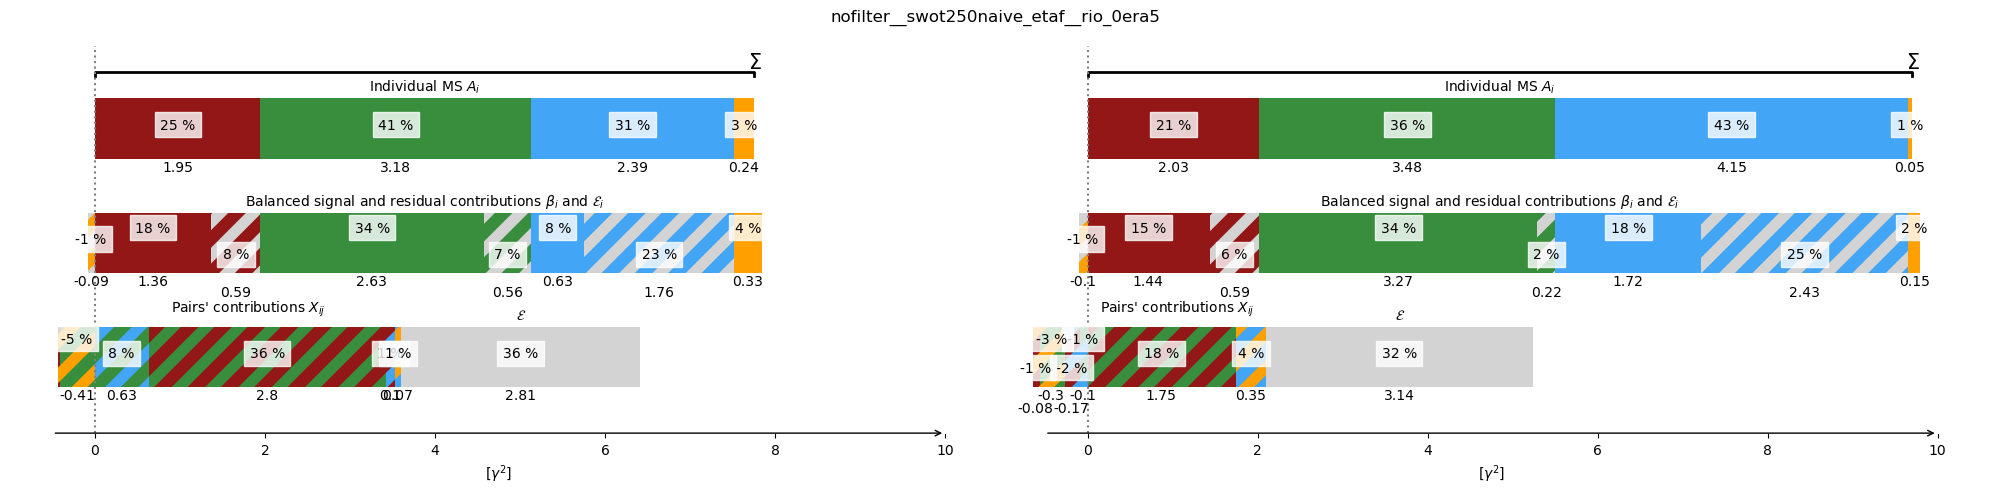

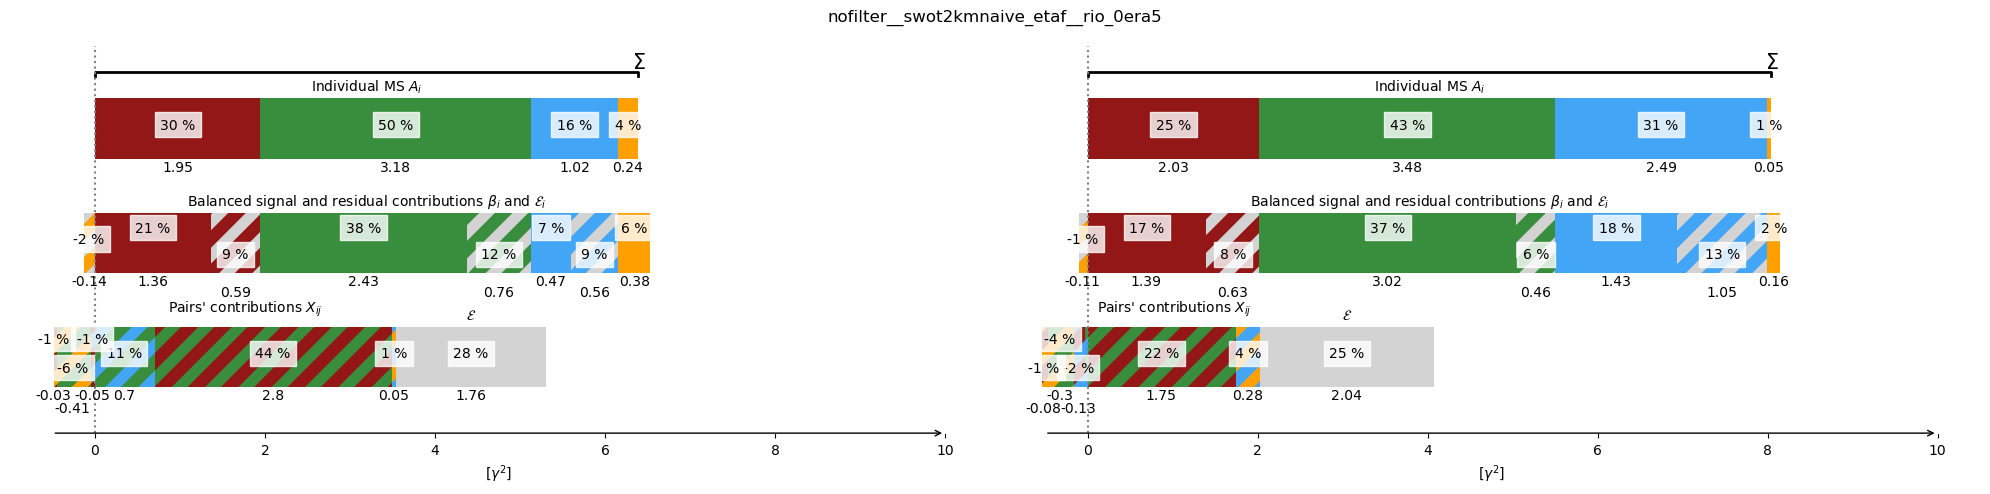

In [6]:
ds = compute_mean_square(DSS, dirname=('x', 'y'))/U2
df = ds.to_dataframe()
print(DSS.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='x', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='y', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '_Xy.png'))

6493
5.577448922054698
2.9016737517358764
8.75575172056855
4.117181099762267
4.7443461837142555
2.114886198471591
8.056278085507104
3.699870275788267


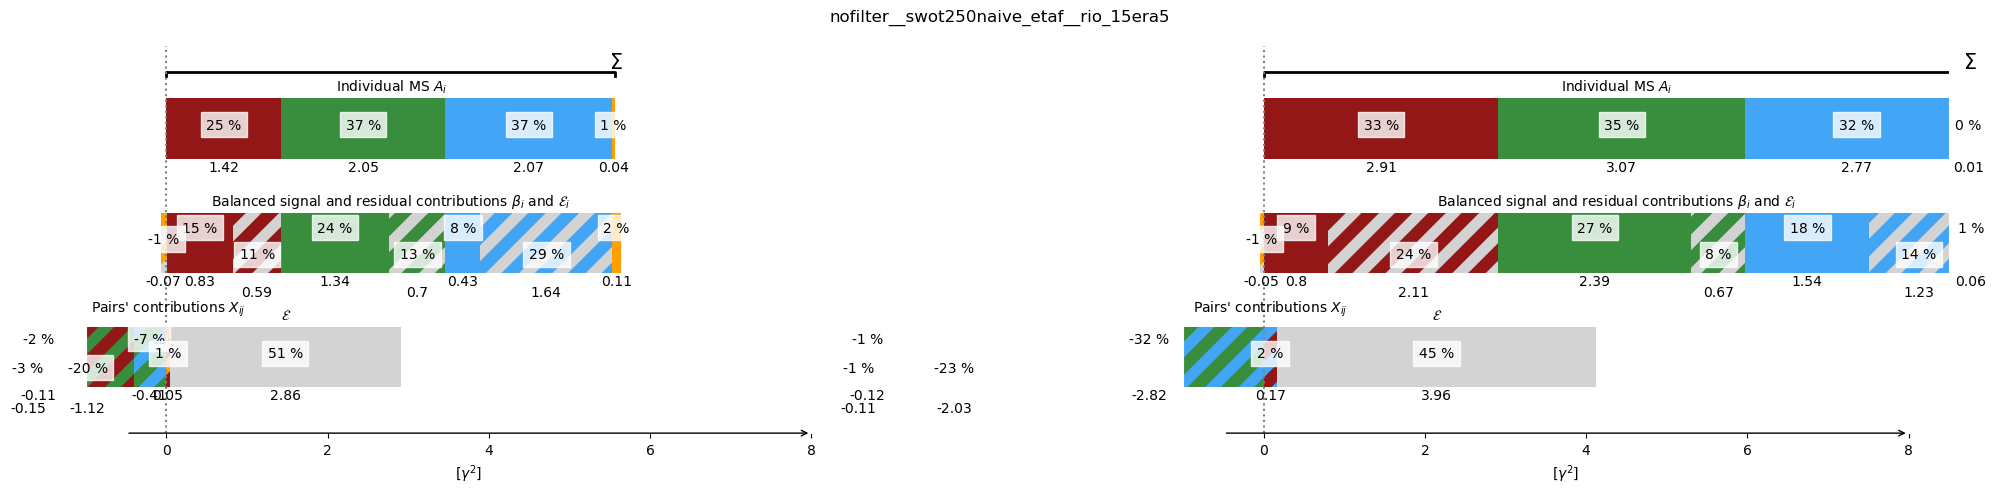

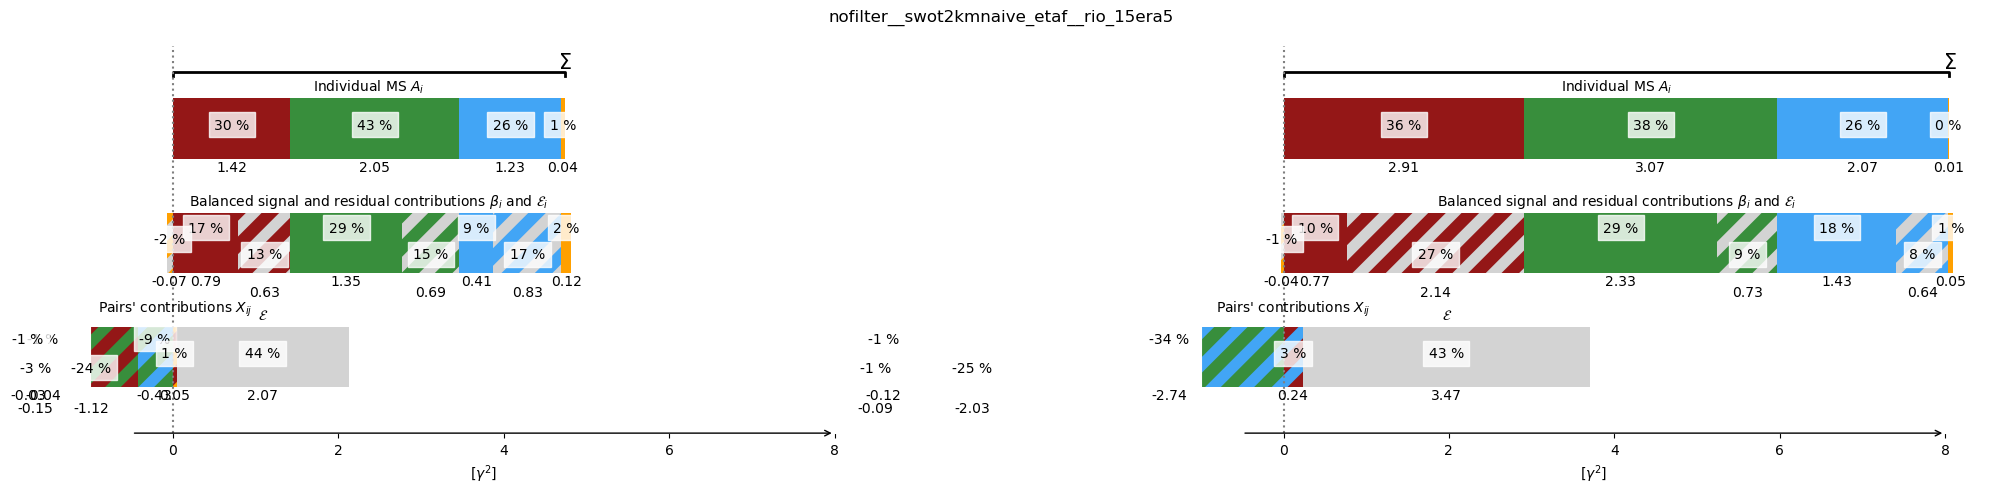

In [9]:
ds = compute_mean_square(DSD, dirname=('x', 'y'))/U2
df = ds.to_dataframe()
print(DSD.sizes['row_number'])
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='x', xlim=[-1, 8])
    synthetic_figure(df.loc[c], axs[1], dir='y', xlim=[-1, 8])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

__________________
## Sensitivity to SWOT-250m filtering

nofilter__swot250naive_etaf__rio_0era5
nofilter__swot250gauss1e3_etaf__rio_0era5
nofilter__swot250gauss2e3_etaf__rio_0era5
nofilter__swot250gauss3e3_etaf__rio_0era5
nofilter__swot250gauss4e3_etaf__rio_0era5
nofilter__swot250gauss5e3_etaf__rio_0era5
7.025788504223055
7.2804475799539965
8.769876426580538
8.818816680720133
6.665989303340561
6.938616602620302
8.35134259566471
8.397585127788632
6.190465839722849
6.441871860777303
7.815365566842426
7.855570213198912
5.806342313158906
6.034874520842535
7.289641610662248
7.334497535788665
5.533283466478967
5.746233846834669
6.8624666139457435
6.916457238345978
5.331190174759487
5.5333737896756094
6.531863950101756
6.588571053830221


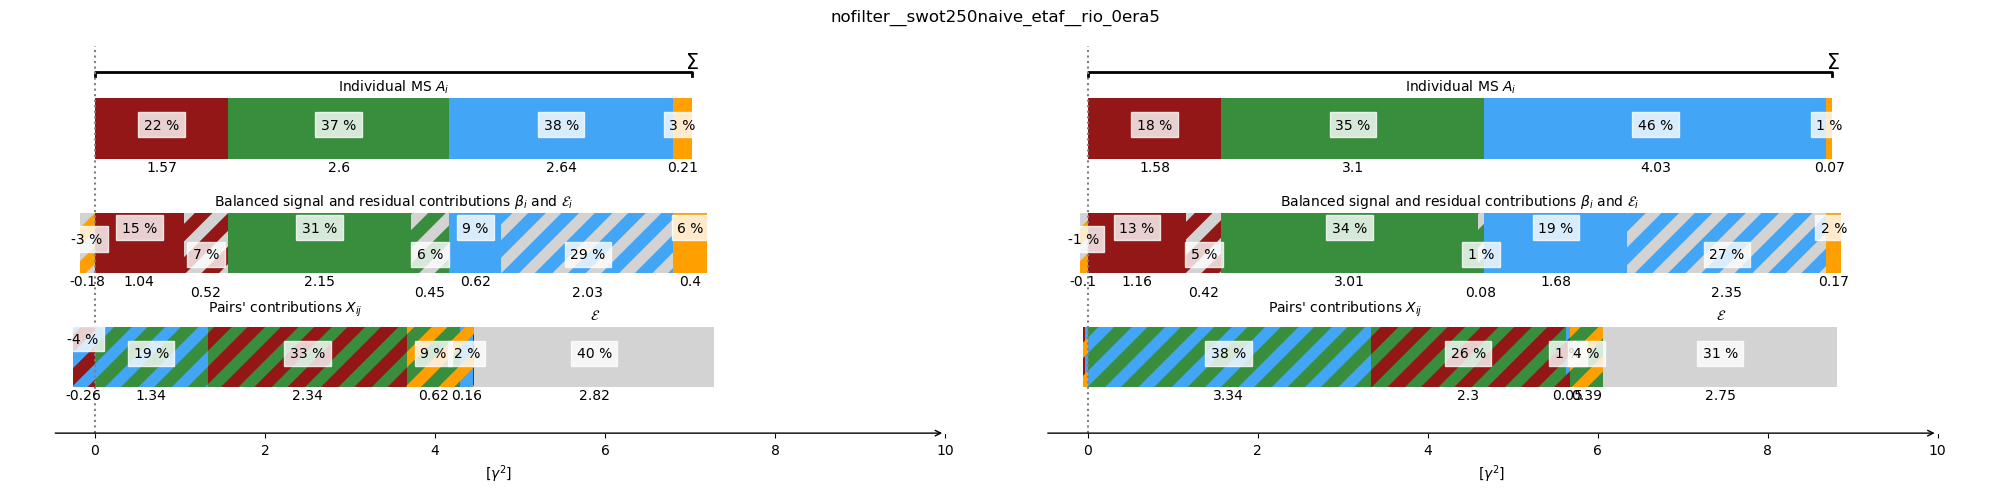

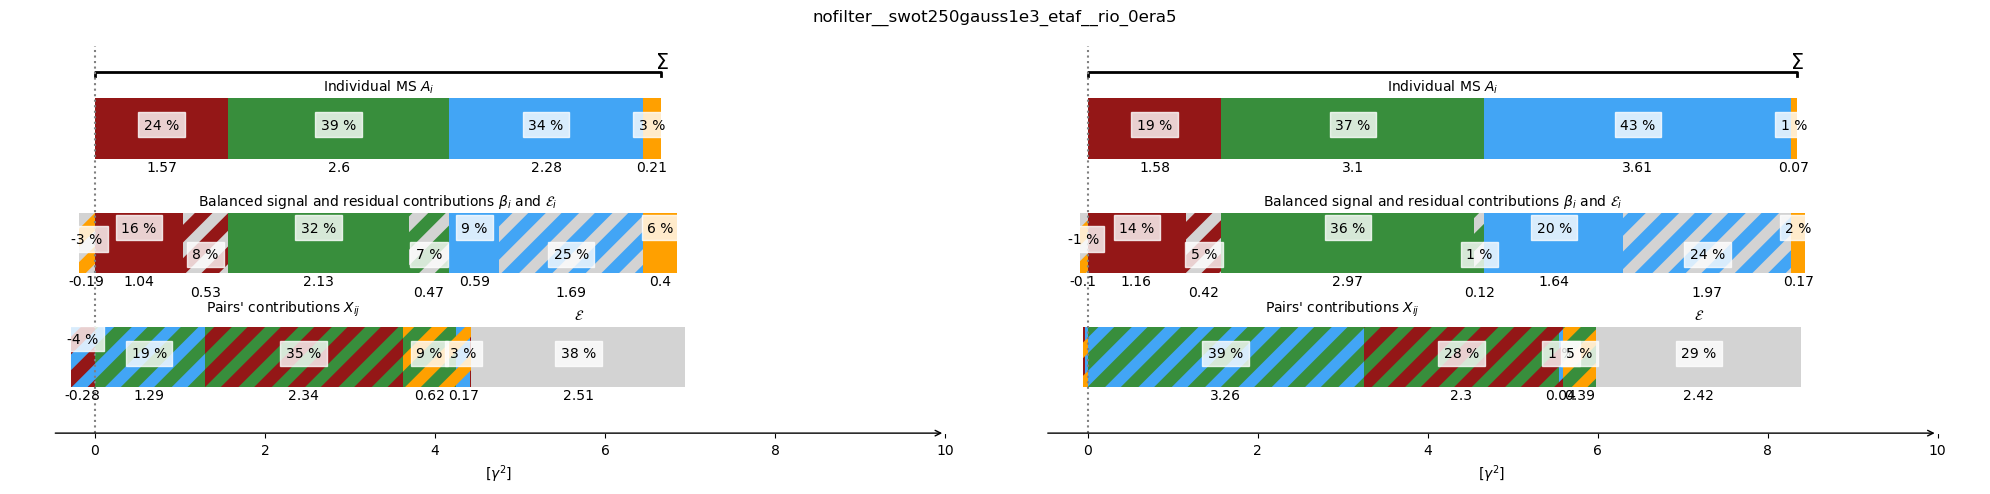

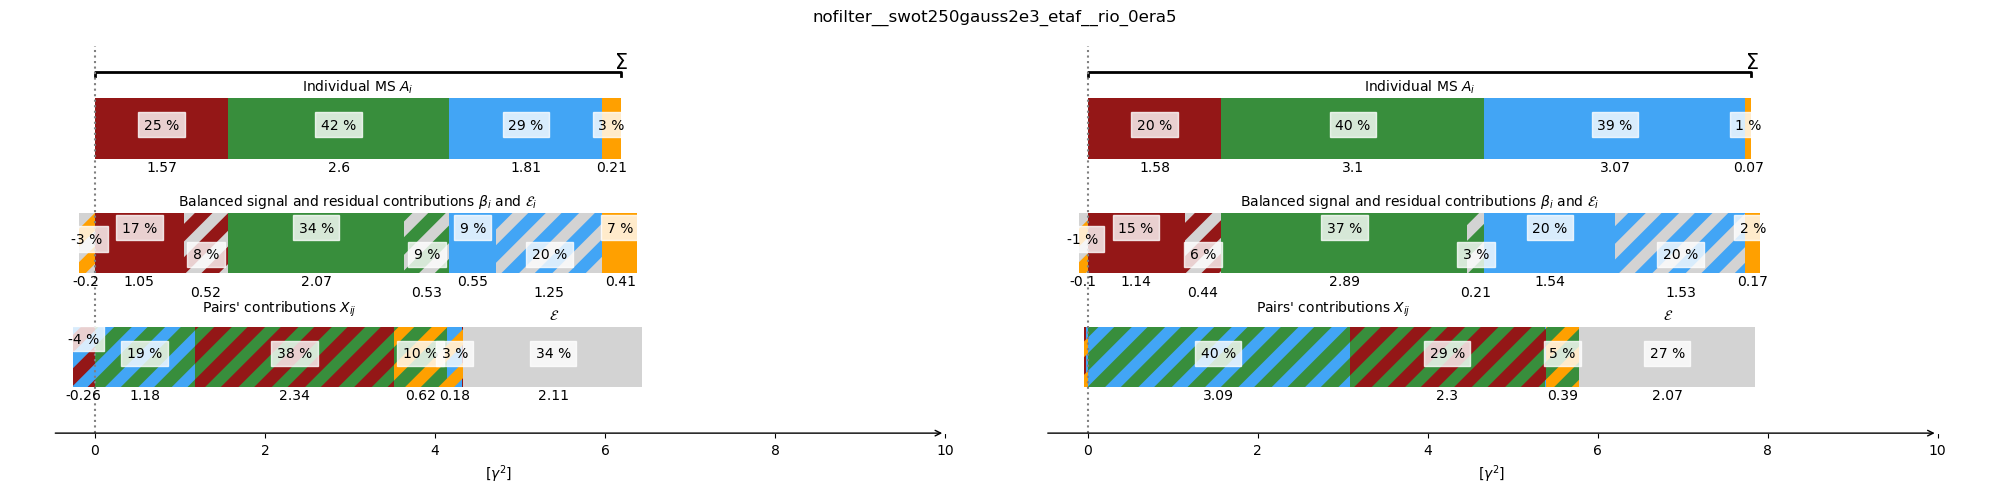

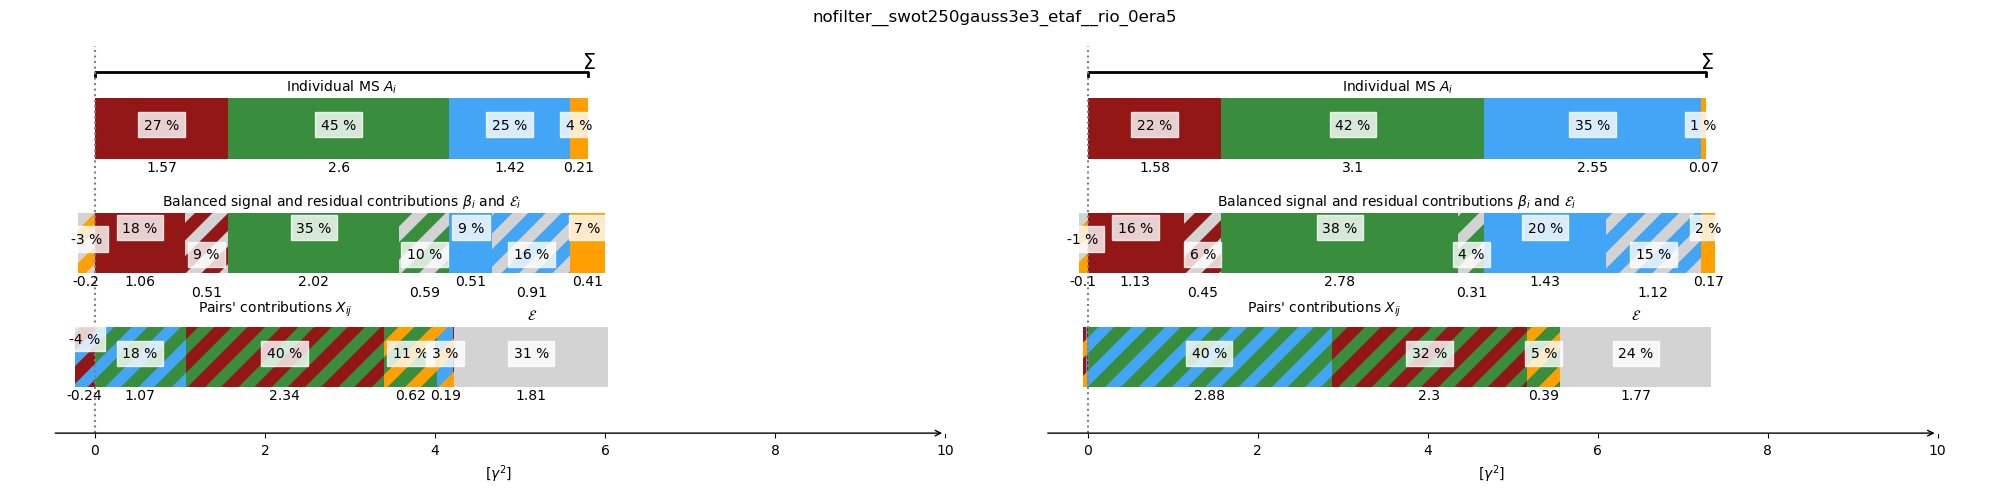

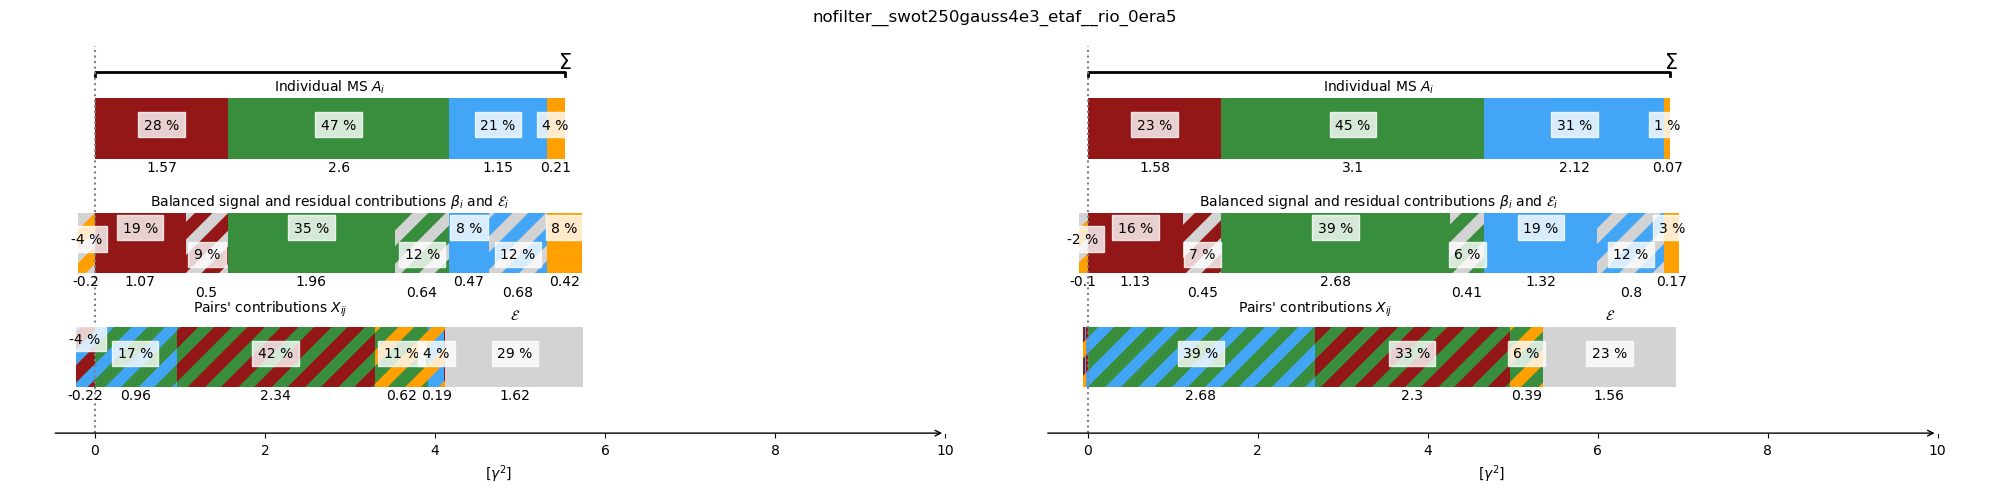

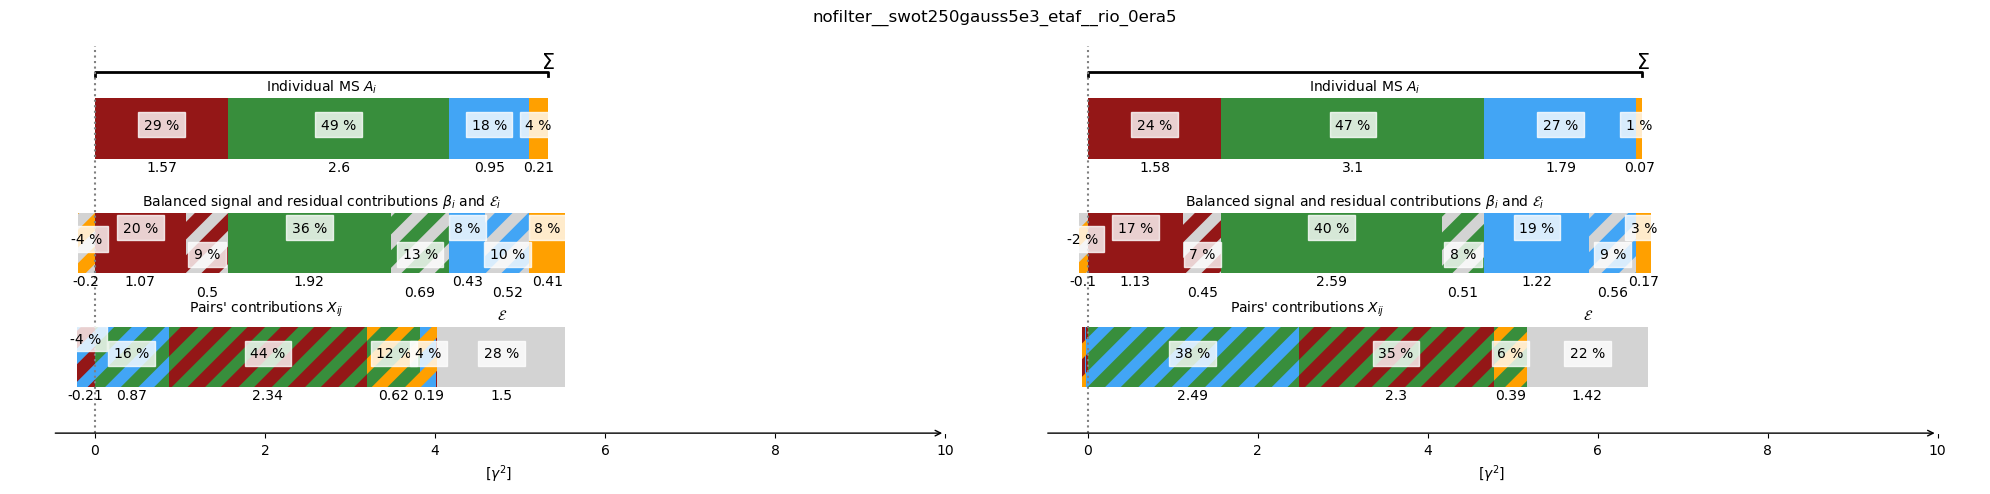

In [9]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot250naive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss1e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
             dict(drifter_key='nofilter', alti_key = 'swot250gauss2e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss3e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss4e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),
            dict(drifter_key='nofilter', alti_key = 'swot250gauss5e3', wd_key = 'era5', ggd_var='etaf', wd_depth='0'),]

DS = dataset_coloc_combs(comb_list, nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')>12).drop_sel(row_number = err_acc).dropna('row_number')
a = 3e-4
DS = DS.where((abs(DS.ggde)<a) & (abs(DS.ggdn)<a), drop=True) #delete ggd outliers
DSS = DS.where(DS.depth==0, drop=True)
ds = compute_mean_square(DSS)/U2
df = ds.to_dataframe()
for c in ds.id_comb.values :
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

In [11]:
dfs = pd.read_csv(ALTI['swot250naive']).set_index('row_number')

In [15]:
dfs

,longitude,latitude,ancillary_surface_classification_flag,cross_track_distance,cvl_distance_to_coast,cvl_swh_model,duacs_editing_flag,duacs_phase_screen,duacs_phase_screen_orbit,duacs_phase_screen_static,...,ggde_cvl_mean_sea_surface_cnes_22_hybrid,ggdn_cvl_mean_sea_surface_cnes_22_hybrid,ggde_cvl_ocean_tide_fes_2022,ggdn_cvl_ocean_tide_fes_2022,ggde_cvl_ssha_reference,ggdn_cvl_ssha_reference,ggde_duacs_ssha_karin_2_calibrated,ggdn_duacs_ssha_karin_2_calibrated,ggde_duacs_ssha_karin_2_filtered,ggdn_duacs_ssha_karin_2_filtered
row_number,,,,,,,,,,,,,,,,,,,,,
0.0,5.246127,42.897523,0.0,-5779.362487,32897.636451,2.713701,0.0,-0.003188,0.0001,-0.000737,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1.0,5.243674,42.896348,0.0,-5973.457221,33000.000000,2.715262,0.0,-0.003111,0.0001,-0.000862,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2.0,5.241153,42.895152,0.0,-6140.164908,33000.000000,2.717080,0.0,-0.003044,0.0001,-0.000844,...,-0.000146,0.000307,-9.311046e-08,-3.727928e-07,-0.000900,-0.000486,-0.000773,-0.000517,8.935359e-07,5.425291e-07
3.0,5.238567,42.893930,0.0,-6278.375380,33000.000000,2.719255,0.0,-0.002989,0.0001,-0.000789,...,-0.000145,0.000307,-7.458341e-07,-1.852712e-06,0.000317,0.000429,0.000436,0.000399,1.102085e-06,2.351449e-06
4.0,5.235922,42.892675,0.0,-6499.500626,33006.934949,2.722001,0.0,-0.002900,0.0001,-0.000692,...,-0.000151,0.000303,-5.252423e-07,-1.960488e-06,0.000098,0.000160,0.000197,0.000135,-1.468553e-05,-1.086013e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405568.0,1.809666,39.312590,0.0,30681.116105,30000.000000,0.372000,0.0,-0.002500,-0.0001,0.000955,...,-0.000139,-0.000224,9.325189e-08,-3.972386e-07,0.000625,-0.000021,0.000513,-0.000047,6.515672e-06,-6.053315e-06
405569.0,1.809406,39.312064,0.0,30709.893906,30000.000000,0.372056,0.0,-0.002506,-0.0001,0.000943,...,-0.000140,-0.000223,1.587991e-07,-6.763202e-07,0.000565,-0.000111,0.000453,-0.000138,5.975908e-06,-5.881196e-06
405570.0,1.809097,39.311556,0.0,30729.549607,30000.000000,0.372063,0.0,-0.002506,-0.0001,0.000929,...,-0.000141,-0.000222,2.030932e-07,-1.408635e-06,0.000495,-0.000252,0.000383,-0.000278,5.712965e-06,-5.351043e-06
